# Notebook 6 — Causal Safety Analysis

**Central question:** Does high traffic density *cause* more near-misses, or
are dense scenes simply located at inherently dangerous road segments?

Correlation cannot answer this — we need causal inference.

This notebook applies:
1. **Propensity Score Matching (PSM)** — estimate Average Treatment Effect (ATE)
   of high agent density on minimum TTC
2. **Inverse Probability Weighting (IPW)** — reweight pseudo-population
3. **Granger Causality** — does acceleration Granger-cause TTC drops?
4. **Counterfactual Analysis** — what would TTC be if speed were 3 m/s lower?
5. **Causal Discovery (PC Algorithm)** — learn the DAG from data

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data.waymo_loader import load_dataset, extract_trajectories
from src.metrics.safety_metrics import batch_ttc, nearest_agent_distances
from src.causal.causal_safety import (
    propensity_score_matching, ipw_ate,
    batch_granger, counterfactual_ttc
)
from src.causal.causal_discovery import pc_algorithm, correlation_dag, dag_summary, plot_dag

sns.set_theme(style='whitegrid')

In [2]:
dataset = load_dataset('../data', max_segments=10)
trajectories = extract_trajectories(dataset['lidar_box'])
trajectories = nearest_agent_distances(trajectories)
ttc_df = batch_ttc(trajectories)
print(f'Loaded {len(trajectories):,} trajectory rows')

Loaded 108,693 trajectory rows


/Users/sachiniweerasekara/Desktop/Waymo_Project/av-safety-evaluation/notebooks/../src/metrics/safety_metrics.py:115: RuntimeWarning: invalid value encountered in divide
  ttc = np.where(closing > 0, gap / closing, np.inf)
/Users/sachiniweerasekara/Desktop/Waymo_Project/av-safety-evaluation/notebooks/../src/metrics/safety_metrics.py:115: RuntimeWarning: divide by zero encountered in divide
  ttc = np.where(closing > 0, gap / closing, np.inf)


## Step 1: Build segment-level analysis table

Each row = one (segment, frame).  Create binary treatment: `high_density` = 1
when agents per frame > median.

In [3]:
# Per-frame agent count
agent_density = (
    trajectories
    .groupby(['segment_id', 'timestamp_us'])['object_id']
    .count()
    .reset_index(name='n_agents')
)

# Join TTC and density
frame_df = ttc_df.merge(agent_density, on=['segment_id', 'timestamp_us'])

# Compute frame-level covariates from trajectories
frame_covariates = (
    trajectories
    .groupby(['segment_id', 'timestamp_us'])
    .agg(mean_speed=('speed', 'mean'),
         mean_acceleration=('acceleration', 'mean'),
         mean_nearest_dist=('nearest_agent_dist', 'mean'))
    .reset_index()
)
frame_df = frame_df.merge(frame_covariates, on=['segment_id', 'timestamp_us'])

# Binary treatment
density_median = frame_df['n_agents'].median()
frame_df['high_density'] = (frame_df['n_agents'] > density_median).astype(int)

# Clip extreme TTC for numerics
frame_df['min_ttc_clipped'] = frame_df['min_ttc'].replace(np.inf, 20.0).clip(0, 20)

print(f'Treated (high density) frames: {frame_df["high_density"].sum():,}')
print(f'Control (low density) frames:  {(1-frame_df["high_density"]).sum():,}')
frame_df.head()

Treated (high density) frames: 953
Control (low density) frames:  970


,segment_id,timestamp_us,min_ttc,near_miss,n_agents,mean_speed,mean_acceleration,mean_nearest_dist,high_density,min_ttc_clipped
0,10203656353524179475_7625_000_7645_000,1522688015070129,0.549877,True,24,4.483809,0.280988,11.091941,0,0.549877
1,10203656353524179475_7625_000_7645_000,1522688015170074,0.440067,True,24,4.476886,0.280980,11.195691,0,0.440067
2,10203656353524179475_7625_000_7645_000,1522688015269987,0.377552,True,25,5.062091,0.321226,11.940249,0,0.377552
3,10203656353524179475_7625_000_7645_000,1522688015369887,0.358990,True,25,5.059863,0.321940,9.731170,0,0.358990
4,10203656353524179475_7625_000_7645_000,1522688015469787,0.380104,True,25,5.056151,0.321940,9.770505,0,0.380104


## Step 2: Propensity Score Matching

In [4]:
confounders = ['mean_speed', 'mean_acceleration', 'mean_nearest_dist']

psm_result = propensity_score_matching(
    frame_df.dropna(subset=confounders + ['min_ttc_clipped']),
    treatment_col='high_density',
    outcome_col='min_ttc_clipped',
    confounder_cols=confounders,
    caliper=0.05,
)
print(psm_result)
print(f'Matched pairs: {psm_result.n_matched}')

ATE(high_density → min_ttc_clipped): -4.9469 [-5.6803, -4.2308]  p=0.0000  ✓ significant
Matched pairs: 399


## Step 3: Inverse Probability Weighting

In [5]:
ipw_result = ipw_ate(
    frame_df.dropna(subset=confounders + ['min_ttc_clipped']),
    treatment_col='high_density',
    outcome_col='min_ttc_clipped',
    confounder_cols=confounders,
)
print(ipw_result)

# Summary comparison
print('\n--- ATE Comparison ---')
print(f'PSM ATE: {psm_result.ate:+.4f} s  (p={psm_result.p_value:.4f})')
print(f'IPW ATE: {ipw_result.ate:+.4f} s  (p={ipw_result.p_value:.4f})')
print('Negative ATE → high density reduces TTC (more dangerous)')

ATE(high_density → min_ttc_clipped): -4.8991 [-5.4732, -4.3250]  p=0.0000  ✓ significant

--- ATE Comparison ---
PSM ATE: -4.9469 s  (p=0.0000)
IPW ATE: -4.8991 s  (p=0.0000)
Negative ATE → high density reduces TTC (more dangerous)


## Step 4: Granger Causality — Does acceleration Granger-cause TTC drops?

In [6]:
# Merge TTC back onto per-object trajectories for time-series analysis
traj_with_ttc = trajectories.merge(
    ttc_df[['segment_id', 'timestamp_us', 'min_ttc']],
    on=['segment_id', 'timestamp_us'], how='left'
)
traj_with_ttc['min_ttc_finite'] = traj_with_ttc['min_ttc'].replace(np.inf, 20.0).clip(0, 20)

granger_df = batch_granger(
    traj_with_ttc,
    cause_col='acceleration',
    effect_col='min_ttc_finite',
    max_lag=5,
    min_track_len=40,
)
print(f'Tracks tested: {len(granger_df)}')
print(f'Significant Granger links: {granger_df["significant"].sum()} ({granger_df["significant"].mean()*100:.1f}%)')
print(f'Mean F-statistic: {granger_df["f_statistic"].mean():.3f}')
granger_df.head(10)

/Users/sachiniweerasekara/Desktop/Waymo_Project/av-safety-evaluation/.venv/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/sachiniweerasekara/Desktop/Waymo_Project/av-safety-evaluation/.venv/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/sachiniweerasekara/Desktop/Waymo_Project/av-safety-evaluation/.venv/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/sachiniweerasekara/Desktop/Waymo_Project/av-safety-evaluation/.venv/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/sachiniweerasekara/Desktop/Waymo_Project/av-safety-evalua

/Users/sachiniweerasekara/Desktop/Waymo_Project/av-safety-evaluation/.venv/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/sachiniweerasekara/Desktop/Waymo_Project/av-safety-evaluation/.venv/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/sachiniweerasekara/Desktop/Waymo_Project/av-safety-evaluation/.venv/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/sachiniweerasekara/Desktop/Waymo_Project/av-safety-evaluation/.venv/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/sachiniweerasekara/Desktop/Waymo_Project/av-safety-evalua

/Users/sachiniweerasekara/Desktop/Waymo_Project/av-safety-evaluation/.venv/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/sachiniweerasekara/Desktop/Waymo_Project/av-safety-evaluation/.venv/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/sachiniweerasekara/Desktop/Waymo_Project/av-safety-evaluation/.venv/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/sachiniweerasekara/Desktop/Waymo_Project/av-safety-evaluation/.venv/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/sachiniweerasekara/Desktop/Waymo_Project/av-safety-evalua

/Users/sachiniweerasekara/Desktop/Waymo_Project/av-safety-evaluation/.venv/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/sachiniweerasekara/Desktop/Waymo_Project/av-safety-evaluation/.venv/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/sachiniweerasekara/Desktop/Waymo_Project/av-safety-evaluation/.venv/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/sachiniweerasekara/Desktop/Waymo_Project/av-safety-evaluation/.venv/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/sachiniweerasekara/Desktop/Waymo_Project/av-safety-evalua

/Users/sachiniweerasekara/Desktop/Waymo_Project/av-safety-evaluation/.venv/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/sachiniweerasekara/Desktop/Waymo_Project/av-safety-evaluation/.venv/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/sachiniweerasekara/Desktop/Waymo_Project/av-safety-evaluation/.venv/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/sachiniweerasekara/Desktop/Waymo_Project/av-safety-evaluation/.venv/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/sachiniweerasekara/Desktop/Waymo_Project/av-safety-evalua

...

/Users/sachiniweerasekara/Desktop/Waymo_Project/av-safety-evaluation/.venv/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/sachiniweerasekara/Desktop/Waymo_Project/av-safety-evaluation/.venv/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/sachiniweerasekara/Desktop/Waymo_Project/av-safety-evaluation/.venv/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/sachiniweerasekara/Desktop/Waymo_Project/av-safety-evaluation/.venv/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/sachiniweerasekara/Desktop/Waymo_Project/av-safety-evalua

/Users/sachiniweerasekara/Desktop/Waymo_Project/av-safety-evaluation/.venv/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/sachiniweerasekara/Desktop/Waymo_Project/av-safety-evaluation/.venv/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/sachiniweerasekara/Desktop/Waymo_Project/av-safety-evaluation/.venv/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/sachiniweerasekara/Desktop/Waymo_Project/av-safety-evaluation/.venv/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/sachiniweerasekara/Desktop/Waymo_Project/av-safety-evalua

Tracks tested: 689
Significant Granger links: 172 (25.0%)
Mean F-statistic: 194467926684.150


/Users/sachiniweerasekara/Desktop/Waymo_Project/av-safety-evaluation/.venv/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/sachiniweerasekara/Desktop/Waymo_Project/av-safety-evaluation/.venv/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/sachiniweerasekara/Desktop/Waymo_Project/av-safety-evaluation/.venv/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/sachiniweerasekara/Desktop/Waymo_Project/av-safety-evaluation/.venv/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/Users/sachiniweerasekara/Desktop/Waymo_Project/av-safety-evalua

,segment_id,object_id,f_statistic,p_value,best_lag,significant
0,10203656353524179475_7625_000_7645_000,-5-3DULJubg1suqUi4Mdtw,6.969290,1.067767e-02,1,True
1,10203656353524179475_7625_000_7645_000,-KpKb_7UDmsdQCf8FS3g9w,21.292442,6.556402e-12,3,True
2,10203656353524179475_7625_000_7645_000,4PYtkkdW-m06MIZKisOQXQ,0.577022,5.641793e-01,2,False
3,10203656353524179475_7625_000_7645_000,7HzhuZfbz0gLLrhYAVCQzg,13.913415,1.015760e-06,3,True
4,10203656353524179475_7625_000_7645_000,8k5pjNF-WPEPZDpotqVlBA,0.372726,6.904642e-01,2,False
5,10203656353524179475_7625_000_7645_000,9wli5e8e7Avq15cf9vPmmw,0.124068,7.254521e-01,1,False
6,10203656353524179475_7625_000_7645_000,BfQfOIZ1ysusKvdrg1QycQ,2.630653,5.541325e-02,4,False
7,10203656353524179475_7625_000_7645_000,BsMZtIXTc6Ydx9gAdpfCJw,6.151461,1.212072e-03,3,True
8,10203656353524179475_7625_000_7645_000,Bw-diIKMdLsOEMGpKwH5WQ,0.346953,5.579832e-01,1,False
9,10203656353524179475_7625_000_7645_000,CgfQUOLj5xXGdRUGJ6qHpg,3.897010,1.288853e-02,3,True


## Step 5: Counterfactual — What if speed were 3 m/s lower?

Counterfactual effect of reducing speed by 3 m/s:
  Mean TTC change: -0.3514 s
  Positive = safer (higher TTC)


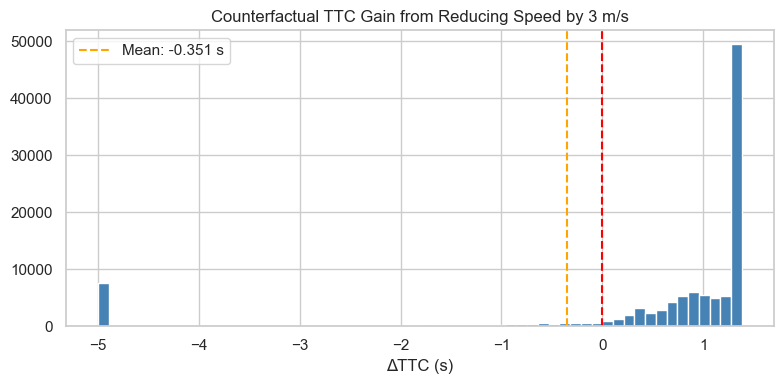

In [7]:
cf_df = counterfactual_ttc(
    traj_with_ttc.dropna(subset=['speed', 'min_ttc_finite']),
    intervention_col='speed',
    intervention_value=traj_with_ttc['speed'].mean() - 3.0,
    outcome_col='min_ttc_finite',
    confounder_cols=['acceleration', 'nearest_agent_dist', 'n_agents']
    if 'n_agents' in traj_with_ttc.columns else ['acceleration'],
)

delta = cf_df['cf_delta_min_ttc_finite'].dropna()
print(f'Counterfactual effect of reducing speed by 3 m/s:')
print(f'  Mean TTC change: {delta.mean():+.4f} s')
print(f'  Positive = safer (higher TTC)')

fig, ax = plt.subplots(figsize=(8, 4))
delta.clip(-5, 5).hist(bins=60, ax=ax, color='steelblue', edgecolor='white')
ax.axvline(0, color='red', linestyle='--')
ax.axvline(delta.mean(), color='orange', linestyle='--', label=f'Mean: {delta.mean():+.3f} s')
ax.set_title('Counterfactual TTC Gain from Reducing Speed by 3 m/s')
ax.set_xlabel('ΔTTC (s)')
ax.legend()
plt.tight_layout()
plt.show()

## Step 6: Causal Discovery — Learn the DAG

In [8]:
features = ['speed', 'acceleration', 'jerk', 'heading_rate', 'nearest_agent_dist', 'min_ttc_finite']
present = [f for f in features if f in cf_df.columns]

dag = correlation_dag(cf_df[present].dropna(), features=present, threshold=0.12)
print('Causal DAG edges learned:')
for u, v in dag.edges():
    print(f'  {u} → {v}')

summary = dag_summary(dag, present)
print('\nNode centrality:')
print(summary.to_string(index=False))

Causal DAG edges learned:
  speed → acceleration
  nearest_agent_dist → speed
  nearest_agent_dist → acceleration

Node centrality:
          variable  in_degree  out_degree  betweenness  is_root  is_sink
             speed          1           1          0.0    False    False
      acceleration          2           0          0.0    False     True
              jerk          0           0          0.0     True     True
      heading_rate          0           0          0.0     True     True
nearest_agent_dist          0           2          0.0     True    False
    min_ttc_finite          0           0          0.0     True     True


In [9]:
fig = plot_dag(dag, title='Learned Causal DAG — AV Safety Features')
plt.show()

/var/folders/jj/khf1rsjs76137181nr0hly600000gn/T/ipykernel_28157/2866035116.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()
